In [321]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations

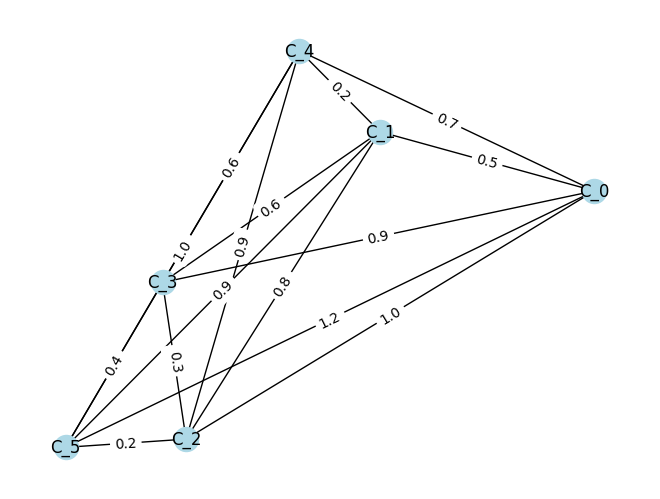

In [322]:
seed = 666

TSP_SIZE = 6
G = nx.Graph()

nodes = [f"C_{i}" for i in range(TSP_SIZE)]
G.add_nodes_from(nodes)

# Random coordinates for cities
rng = np.random.default_rng(seed)
pos = {node: rng.random(2) * 2 for node in nodes}

# Add edges with both distance and pheromone
for n1, n2 in combinations(nodes, 2):
    x1, y1 = pos[n1]
    x2, y2 = pos[n2]
    dist = round(np.sqrt((x1 - x2)**2 + (y1 - y2)**2), 1)

    G.add_edge(
        n1,
        n2,
        distance=dist,   # fixed heuristic cost
        pheromone=1.0    # initial pheromone
    )

# Draw edge labels as distances
distance_labels = {
    e: G[e[0]][e[1]]["distance"]
    for e in G.edges()
}

# Normalize for better visuals
pheromones = [G[e[0]][e[1]]["pheromone"] for e in G.edges()]
max_weight = max(pheromones)
edge_widths = [G[e[0]][e[1]]["pheromone"] / max_weight for e in G.edges()]

nx.draw(G, pos, with_labels=True, node_color="lightblue", width=edge_widths)
nx.draw_networkx_edge_labels(G, pos, edge_labels=distance_labels)

plt.show()

In [323]:
# dump graph to text
for n1, n2 in G.edges():
    dist = G[n1][n2]["distance"]
    pheromone = G[n1][n2]["pheromone"]
    print(f"{n1} -- {n2}: distance={dist}, pheromone={pheromone}")

C_0 -- C_1: distance=0.5, pheromone=1.0
C_0 -- C_2: distance=1.0, pheromone=1.0
C_0 -- C_3: distance=0.9, pheromone=1.0
C_0 -- C_4: distance=0.7, pheromone=1.0
C_0 -- C_5: distance=1.2, pheromone=1.0
C_1 -- C_2: distance=0.8, pheromone=1.0
C_1 -- C_3: distance=0.6, pheromone=1.0
C_1 -- C_4: distance=0.2, pheromone=1.0
C_1 -- C_5: distance=0.9, pheromone=1.0
C_2 -- C_3: distance=0.3, pheromone=1.0
C_2 -- C_4: distance=0.9, pheromone=1.0
C_2 -- C_5: distance=0.2, pheromone=1.0
C_3 -- C_4: distance=0.6, pheromone=1.0
C_3 -- C_5: distance=0.4, pheromone=1.0
C_4 -- C_5: distance=1.0, pheromone=1.0


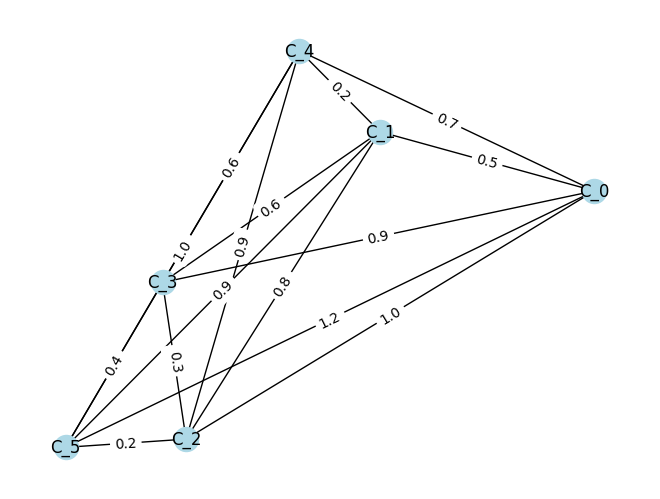

In [324]:
# pick two distinct nodes safely
nodes = list(G.nodes())
node1 = np.random.choice(nodes)
node2 = np.random.choice([n for n in nodes if n != node1])

# update one random edge weight
#G[node1][node2]["pheromone"] = np.random.randint(1, 10)

# refresh weights + max_weight AFTER updating
weights = nx.get_edge_attributes(G, "pheromone")
max_weight = max(weights.values())

# widths must be in the same edge order as G.edges()
edge_widths = [weights[e] / max_weight for e in G.edges()]

plt.figure()

nx.draw(G, pos, with_labels=True, node_color="lightblue", width=edge_widths)
nx.draw_networkx_edge_labels(G, pos, edge_labels=distance_labels)
plt.show()

In [325]:
N = 5 # number of ants
alpha = 2
beta = 2
rho = 0.3
Q = 100

In [326]:
# distance, cost, what ever that is to be minimized: G[u][v]["distance"]

# [heuristic] desirability, fitness, what ever that is to be maximized
def update_costs():
    for n1, n2 in combinations(nodes, 2):
        G[n1][n2]["eta"] = 1 / G[n1][n2]["distance"]

def update_scores():
    # alpha : importance of pheromone
    # beta : importance of [heuristic]
    scores = []
    for n1, n2 in combinations(nodes, 2):
        G[n1][n2]["score"] = G[n1][n2]["pheromone"]**alpha * G[n1][n2]["eta"]**beta
        scores.append(G[n1][n2]["score"])
    return scores

In [327]:
update_costs()

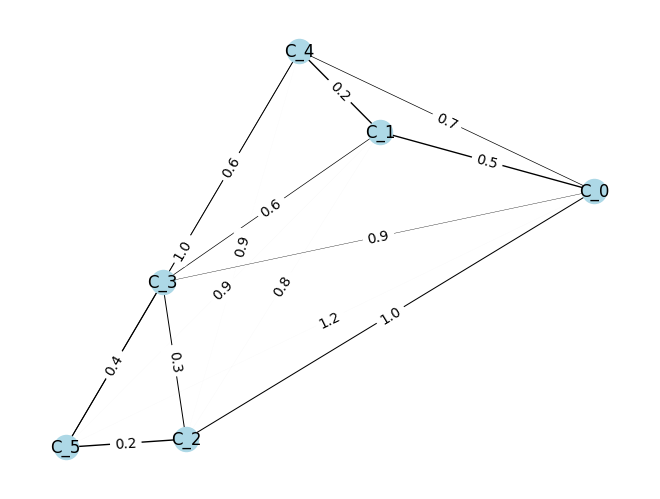

In [328]:
update_scores()
T = [] # list of tours
L = [] # list of tour lengths
for ant in range(N):
    allowed_nodes = set(nodes)
    tour = []
    current_node = np.random.choice(nodes)
    tour.append(current_node)
    allowed_nodes.remove(current_node)
    for i in range(TSP_SIZE - 1):
        # get neighbors and their scores
        neighbors = [n for n in allowed_nodes]
        scores = [G[current_node][n]["score"] for n in neighbors]

        # convert scores to probabilities
        total_score = sum(scores)
        probabilities = [s / total_score for s in scores]

        # choose next node based on probabilities
        next_node = np.random.choice(neighbors, p=probabilities)
        tour.append(next_node)
        allowed_nodes.remove(next_node)
        current_node = next_node
    T.append(tour)
    T_L = sum(G[tour[i]][tour[i+1]]["distance"] for i in range(TSP_SIZE - 1))
    T_L += G[tour[-1]][tour[0]]["distance"] # return to start
    L.append(T_L)

# pheromone update
for n1, n2 in combinations(nodes, 2):
    G[n1][n2]["pheromone"] *= (1 - rho) # evaporation
# deposit
for ant in range(N):
    tour = T[ant]
    deposit = Q / L[ant]

    for i in range(TSP_SIZE - 1):
        u = tour[i]
        v = tour[i + 1]
        G[u][v]["pheromone"] += deposit

    # return to start
    G[tour[-1]][tour[0]]["pheromone"] += deposit


weights = nx.get_edge_attributes(G, "pheromone")
max_weight = max(weights.values())
edge_widths = [weights[e] / max_weight for e in G.edges()]
nx.draw(G, pos, with_labels=True, node_color="lightblue", width=edge_widths)
nx.draw_networkx_edge_labels(G, pos, edge_labels=distance_labels)
plt.show()

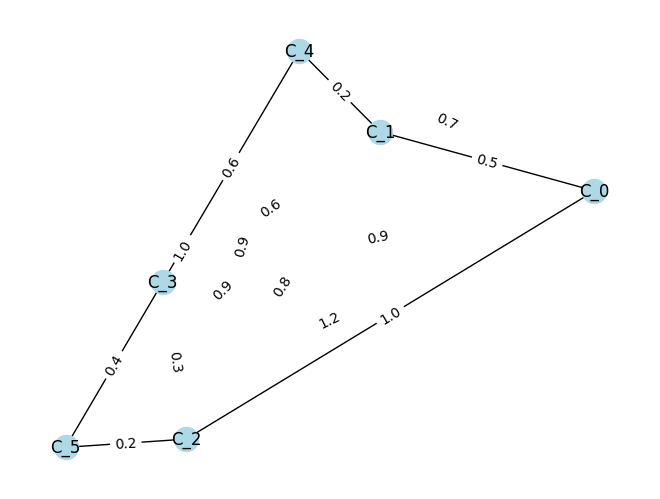

In [329]:
for iter in range(100):
    update_scores()
    T = [] # list of tours
    L = [] # list of tour lengths
    for ant in range(N):
        allowed_nodes = set(nodes)
        tour = []
        current_node = np.random.choice(nodes)
        tour.append(current_node)
        allowed_nodes.remove(current_node)
        for i in range(TSP_SIZE - 1):
            # get neighbors and their scores
            neighbors = [n for n in allowed_nodes]
            scores = [G[current_node][n]["score"] for n in neighbors]

            # convert scores to probabilities
            total_score = sum(scores)
            probabilities = [s / total_score for s in scores]

            # choose next node based on probabilities
            next_node = np.random.choice(neighbors, p=probabilities)
            tour.append(next_node)
            allowed_nodes.remove(next_node)
            current_node = next_node
        T.append(tour)
        T_L = sum(G[tour[i]][tour[i+1]]["distance"] for i in range(TSP_SIZE - 1))
        T_L += G[tour[-1]][tour[0]]["distance"] # return to start
        L.append(T_L)

    # pheromone update
    for n1, n2 in combinations(nodes, 2):
        G[n1][n2]["pheromone"] *= (1 - rho) # evaporation
    # deposit
    for ant in range(N):
        tour = T[ant]
        deposit = Q / L[ant]

        for i in range(TSP_SIZE - 1):
            u = tour[i]
            v = tour[i + 1]
            G[u][v]["pheromone"] += deposit

        # return to start
        G[tour[-1]][tour[0]]["pheromone"] += deposit


weights = nx.get_edge_attributes(G, "pheromone")
max_weight = max(weights.values())
edge_widths = [weights[e] / max_weight for e in G.edges()]
nx.draw(G, pos, with_labels=True, node_color="lightblue", width=edge_widths)
nx.draw_networkx_edge_labels(G, pos, edge_labels=distance_labels)
plt.show()